# final working

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
df=pd.read_csv("data/sroted_adbl.csv")

In [3]:
df.head(1)

,Date,Open,High,Low,Close,Qty
0,9/2/2010,153.0,193.0,178.0,255.0,60.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3303 entries, 0 to 3302
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3303 non-null   object 
 1   Open    3303 non-null   float64
 2   High    3303 non-null   float64
 3   Low     3303 non-null   float64
 4   Close   3303 non-null   float64
 5   Qty     3303 non-null   float64
dtypes: float64(5), object(1)
memory usage: 155.0+ KB


In [5]:
# df.drop("Turnover", axis=1, inplace=True)

df['Date'] = pd.to_datetime(df['Date']) 

df.set_index('Date', inplace=True)
# df = df.apply(lambda x: x.astype(str).str.replace(',', '', regex=True))

df['pchange'] = df['Close'].pct_change()*100
df.isnull().sum()

Open       0
High       0
Low        0
Close      0
Qty        0
pchange    1
dtype: int64

In [6]:
#removing null values by bfill:
df.bfill(inplace=True)

# df.sort_values(by=["Date"], inplace=True, ascending=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3303 entries, 2010-09-02 to 2025-02-27
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Open     3303 non-null   float64
 1   High     3303 non-null   float64
 2   Low      3303 non-null   float64
 3   Close    3303 non-null   float64
 4   Qty      3303 non-null   float64
 5   pchange  3303 non-null   float64
dtypes: float64(6)
memory usage: 180.6 KB


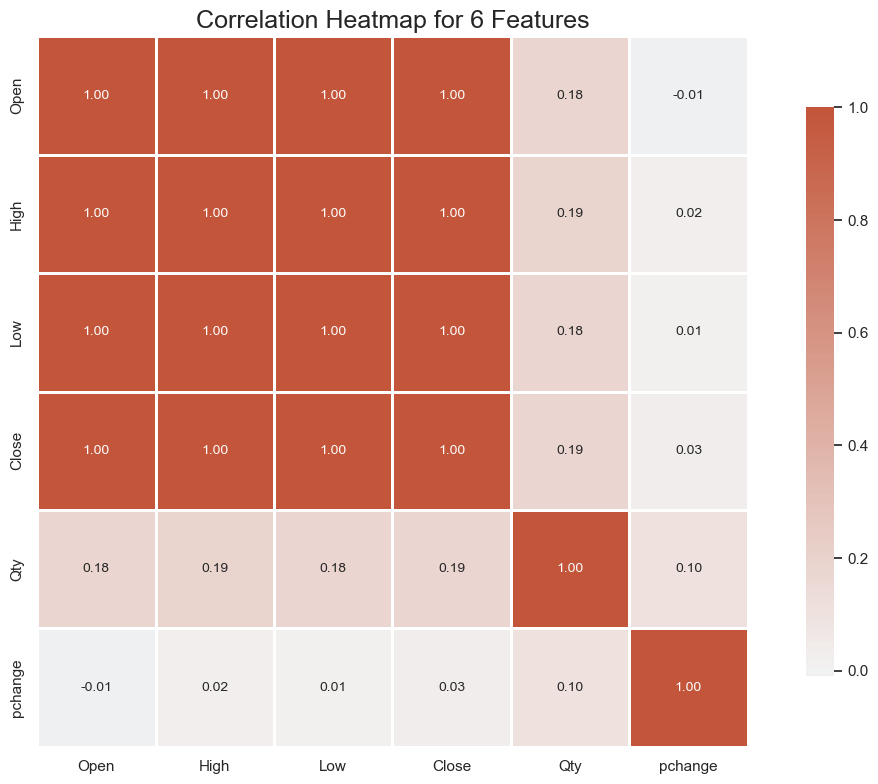

In [8]:
# Step 1: Calculate the correlation matrix
import seaborn as sns
corr_matrix = df.corr()

# Step 2: Plot the heatmap using Seaborn
plt.figure(figsize=(12, 8))  # Adjust size as per your dataset

# Create a custom diverging color palette
sns.set(style="white")  # Set style for better presentation
cmap = sns.diverging_palette(230, 20, as_cmap=True)  # Diverging color map

# Create heatmap with annotation and color intensity
sns.heatmap(corr_matrix, 
            annot=True,             # Annotate the values
            cmap=cmap,              # Use diverging palette for better clarity
            center=0,               # Center the colors around 0
            square=True,            # Square-shaped grid
            linewidths=0.8,         # Line width between cells
            fmt=".2f",              # Formatting for correlation values
            cbar_kws={"shrink": 0.8},  # Adjust color bar size
            annot_kws={"size": 10})    # Font size of annotations

# Step 3: Title and display the plot
plt.title(f'Correlation Heatmap for {len(df.columns)} Features', fontsize=18)
plt.tight_layout()  # Make sure everything fits
plt.show()

In [9]:
# to check numeric ways of this data:
# correlation_matrix = df.corr(numeric_only=True)
# print(correlation_matrix)

In [10]:

df.describe()

,Open,High,Low,Close,Qty,pchange
count,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000,3303.000000
mean,365.712104,370.728853,359.763457,365.528277,26152.688768,0.025879
std,158.387102,161.156751,155.490699,158.695414,47911.559327,2.681784
min,101.000000,103.000000,101.000000,101.000000,20.000000,-45.882353
25%,248.950000,251.000000,244.000000,247.750000,4127.500000,-0.961538
50%,367.000000,371.400000,360.000000,366.000000,11469.000000,0.000000
75%,455.000000,463.000000,449.400000,455.000000,28802.000000,0.925926
max,1082.000000,1113.000000,1048.000000,1082.000000,800592.000000,32.203390


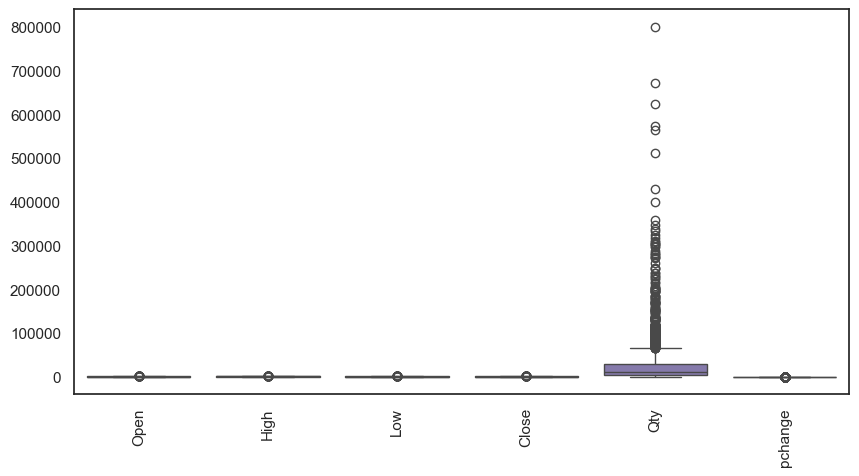

In [11]:
#Checking Outliers by box plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.boxplot(data=df)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.show()

* To remove outliers, we can use min max scaler to to range the values between certain values , also we use clip it using IQR and there are also other ways to remove ouliers

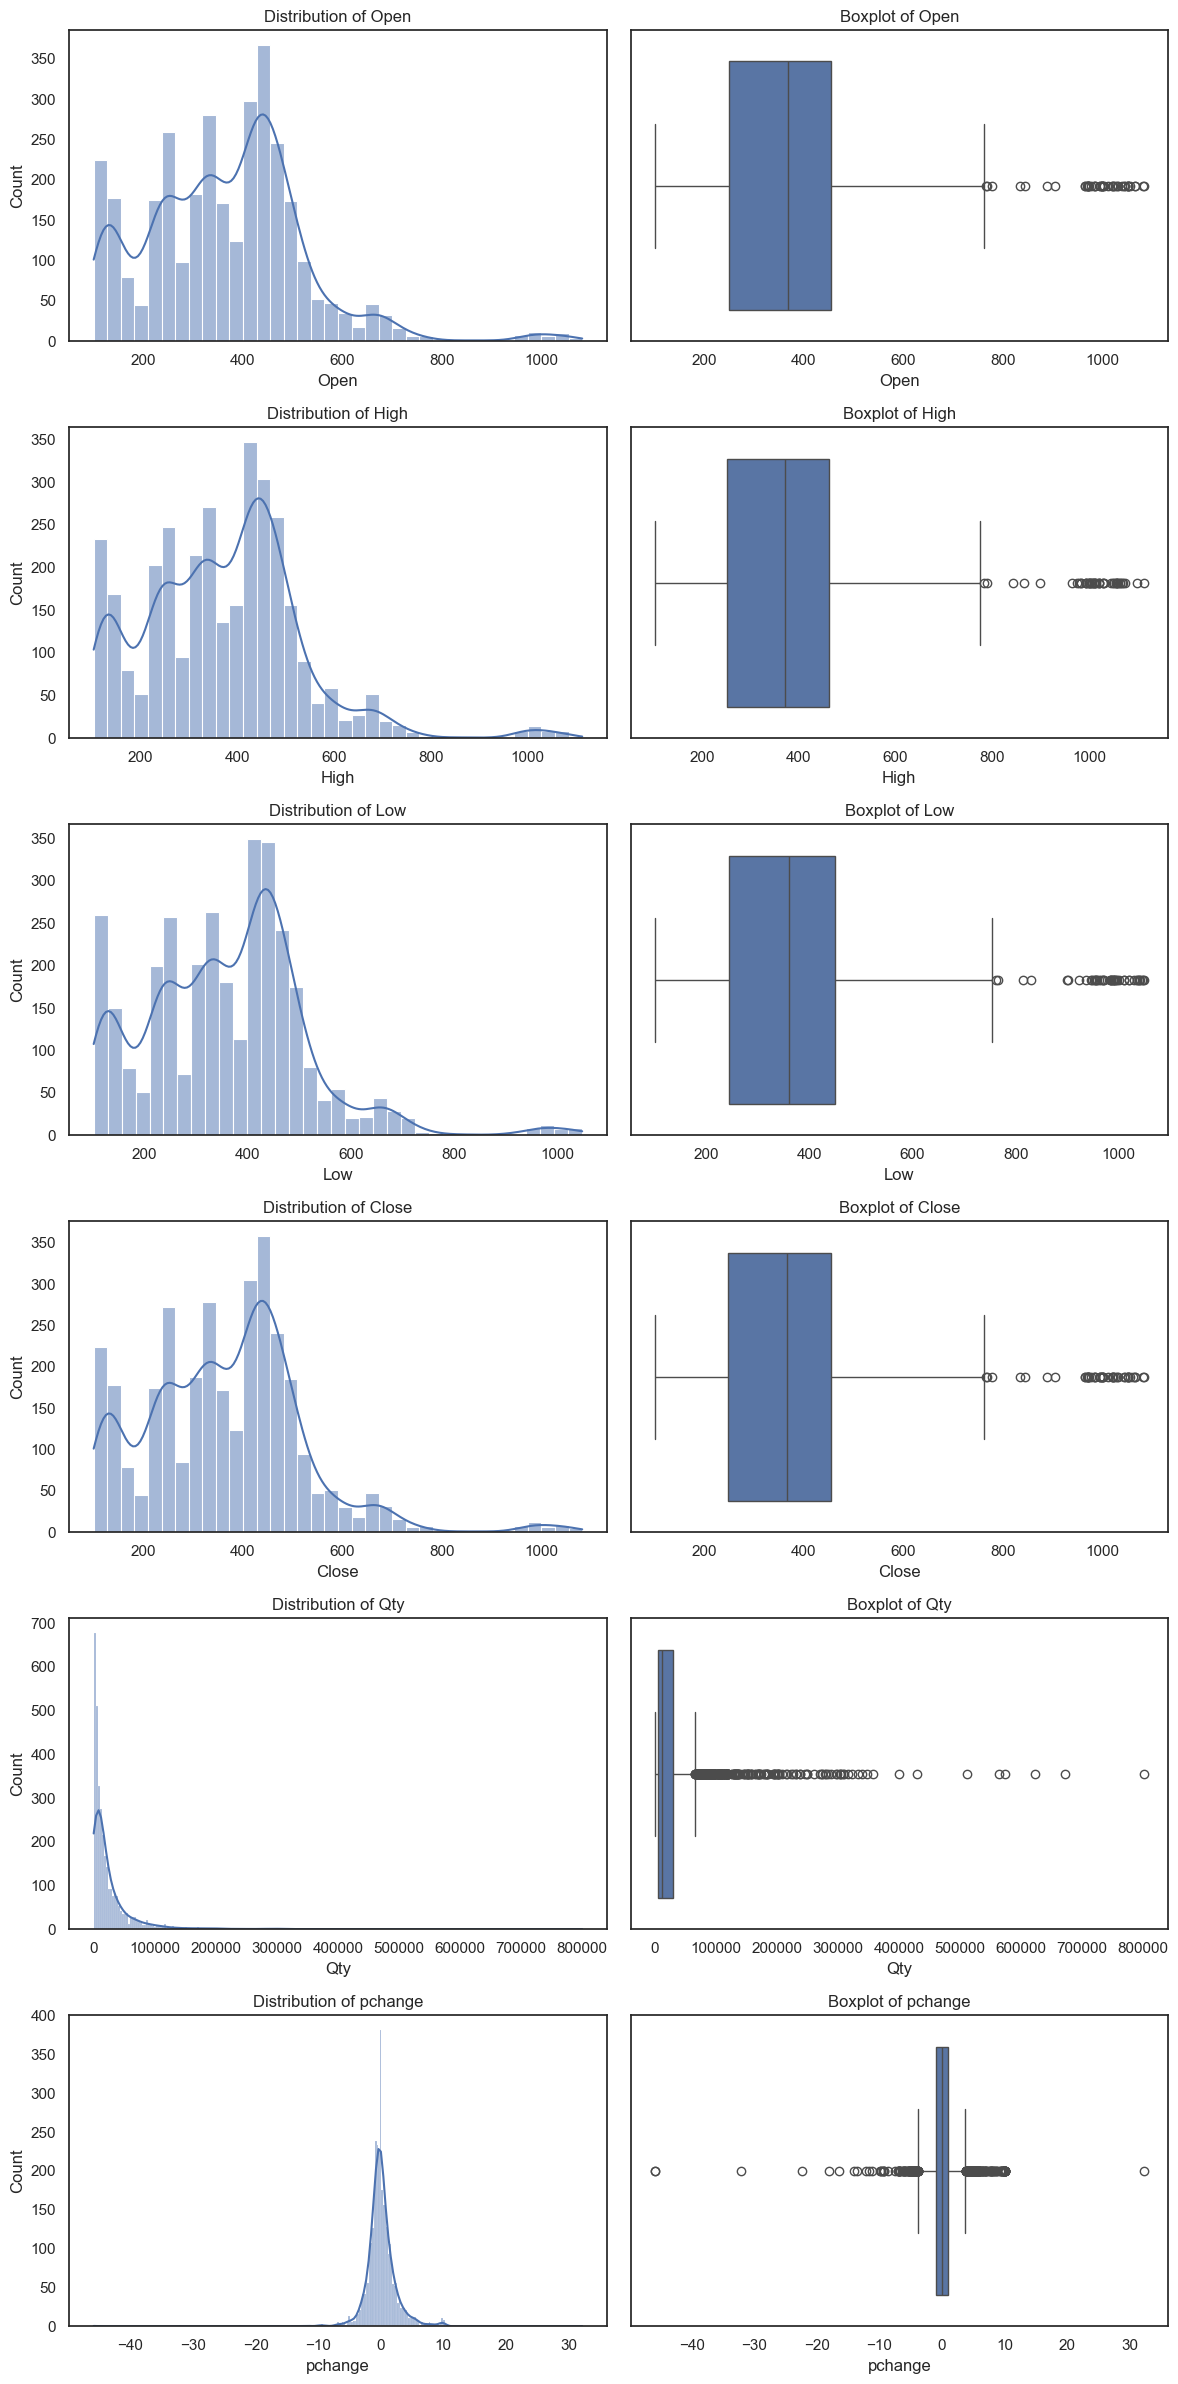

In [12]:
# Calculate rows needed based on the number of columns
numerical_data = df.select_dtypes(include=['float64'])
n_cols = len(numerical_data.columns)
n_rows = n_cols

# Adjust figsize dynamically
plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(numerical_data.columns):
    # Create a subplot for the distribution plot
    plt.subplot(n_rows, 2, 2 * i + 1)
    # sns.histplot(numerical_data[col], kde=True, bins=30)  # Updated to use sns.histplot
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
     # Create a subplot for the boxplot
    plt.subplot(n_rows, 2, 2 * i + 2)
    sns.boxplot(x=numerical_data[col])
    plt.title(f'Boxplot of {col}')

# Adjustjustment on  layout to prevent overlap
plt.tight_layout()
plt.show()

In [13]:
# def find_outliers_iqr_multiple_columns(df,columns):
#     """
#     Identify outliers in multiple specified columns of a data frame using the IQR method.
#     """
#     outliers_summary = {}

#     for column in columns:

#         percentile25 = df[column].quantile(0.25)
#         percentile75 = df[column].quantile(0.75)
#         iqr = percentile75 - percentile25
#         lower_limit = percentile25 - 1.5 * iqr
#         upper_limit = percentile75 + 1.5 * iqr


#         lower_outliers = df[df[column] < lower_limit]
#         upper_outliers = df[df[column] > upper_limit]

#         outliers_summary[column] = {
#             'lower_outliers_count': len(lower_outliers),
#             'upper_outliers_count': len(upper_outliers),
#             'lower_limit': lower_limit,
#             'upper_limit': upper_limit
#         }

#     return outliers_summary
# columns = df.select_dtypes(include=['float64', 'int64'])
# outliers_summary = find_outliers_iqr_multiple_columns(df, columns)


# for column, summary in outliers_summary.items():
#     print(f"\nColumn: {column}")
#     print(f"Lower Outliers Count: {summary['lower_outliers_count']}")
#     print(f"Upper Outliers Count: {summary['upper_outliers_count']}")
#     print(f"Lower Limit: {summary['lower_limit']}")
#     print(f"Upper Limit: {summary['upper_limit']}")

In [14]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Check for outliers in stock prices
for col in df:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col} - Outliers Found: {len(outliers)}")

Open - Outliers Found: 46
High - Outliers Found: 46
Low - Outliers Found: 45
Close - Outliers Found: 47
Qty - Outliers Found: 306
pchange - Outliers Found: 267


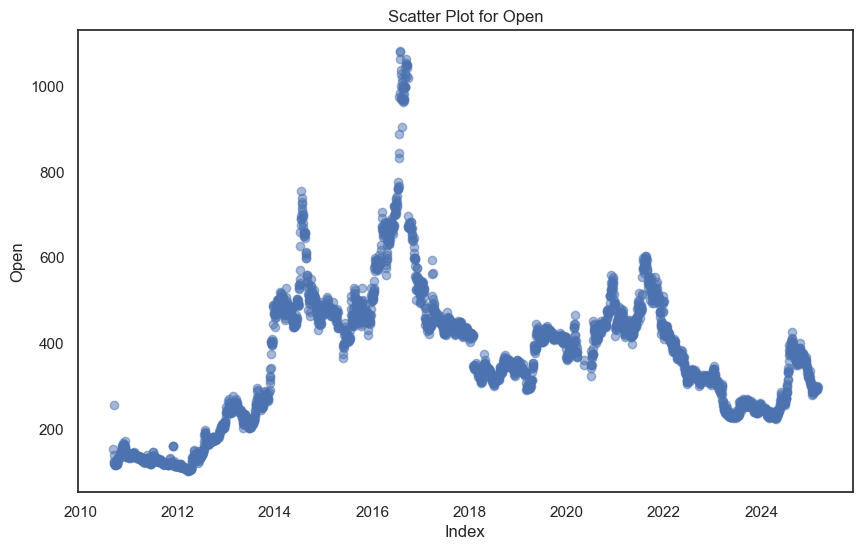

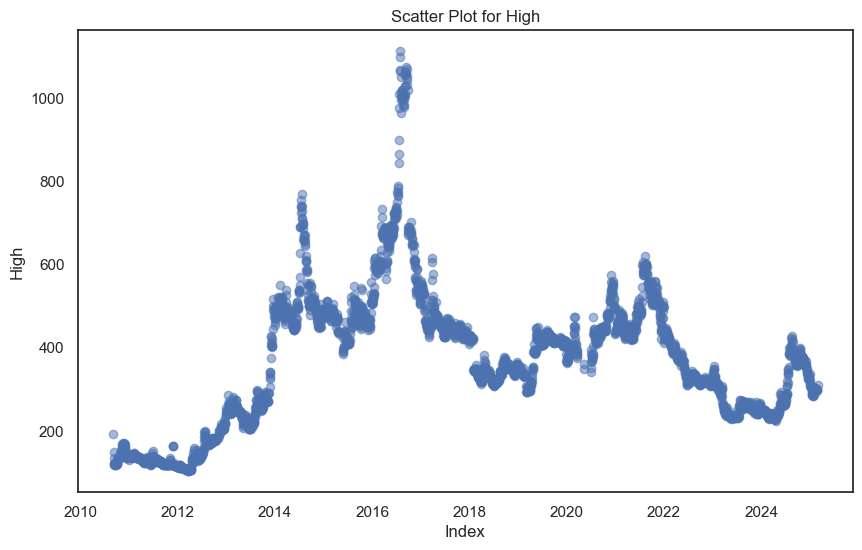

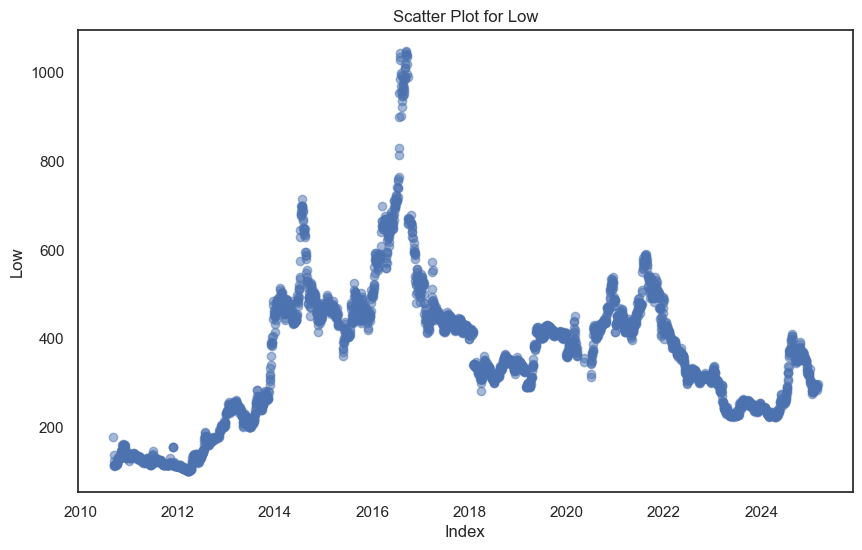

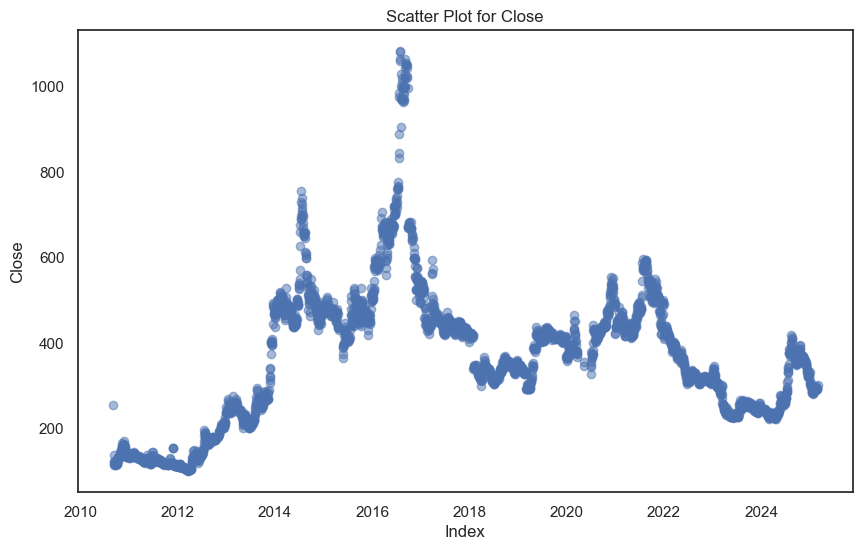

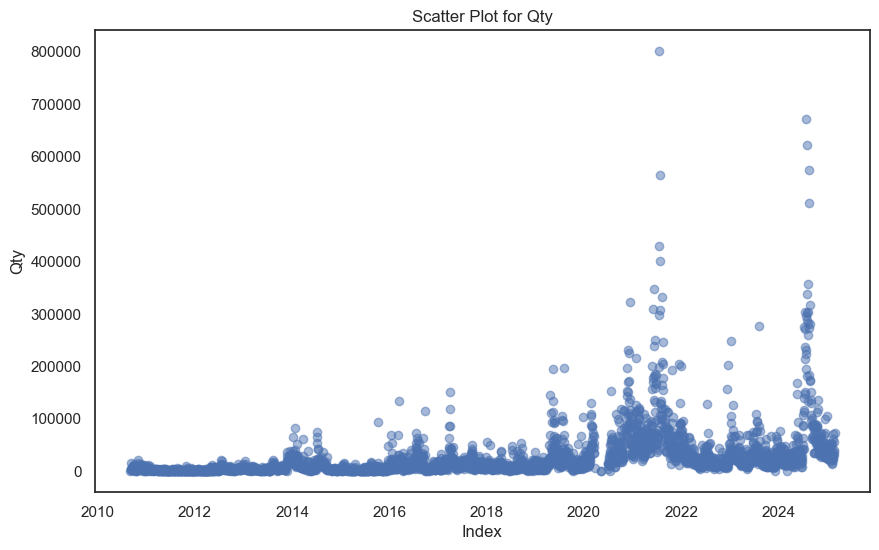

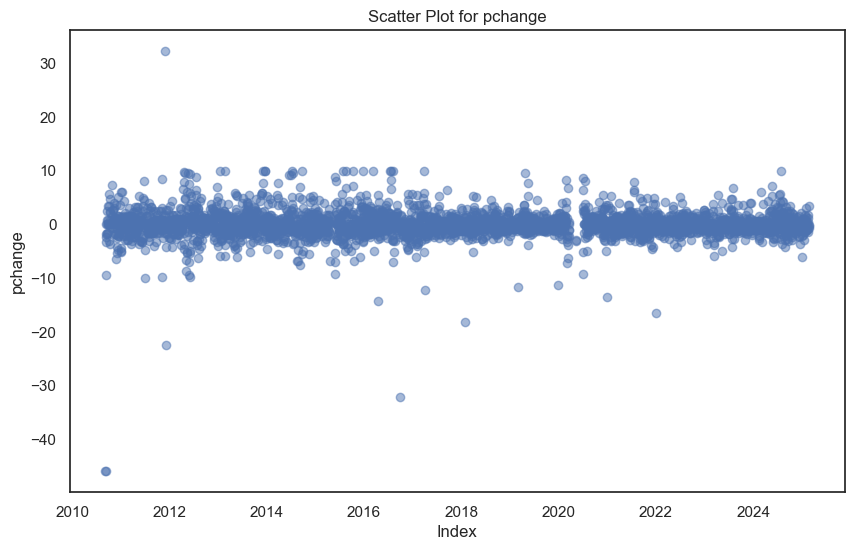

In [15]:
import matplotlib.pyplot as plt

# Plot scatter plot for each numerical column to check for outliers
for column in numerical_data.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df.index, df[column], alpha=0.5)
    plt.title(f'Scatter Plot for {column}')
    plt.xlabel('Index')
    plt.ylabel(column)
    plt.show()

In [16]:
#removing outliers

# for col in df:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     df[col] = df[col].clip(lower_bound, upper_bound)

#note: as data is taken from authenticated source, so outliers are not removed because it might have some important information.

In [17]:
# #checking outliers after removing it from above code:
# def detect_outliers_iqr(data, column):
#     Q1 = data[column].quantile(0.25)
#     Q3 = data[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
#     return outliers

# # Check for outliers in stock prices
# for col in df:
#     outliers = detect_outliers_iqr(df, col)
#     print(f"{col} - Outliers Found: {len(outliers)}")

#note: not checked as outliers are not removed

In [18]:
#after removing outliers, checking box plot again:

# plt.figure(figsize=(10, 5))
# sns.boxplot(data=df)
# plt.xticks(rotation=90)  # Rotate x-axis labels for readability
# plt.show()

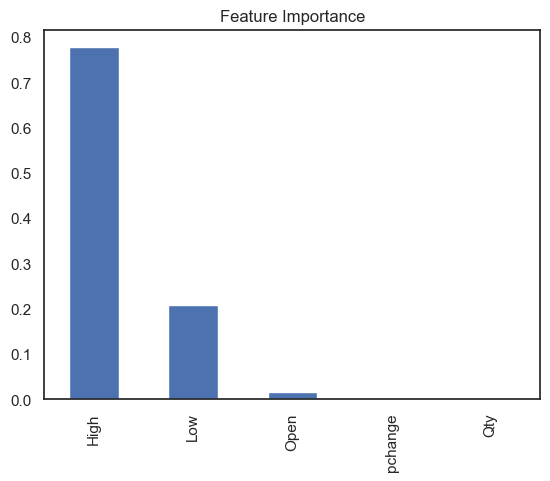

In [19]:
#checking feature imortance:
from sklearn.ensemble import RandomForestRegressor

# Select numerical columns
features = df.columns.drop(['Close'])
X = df[features]
y = df['Close']

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()


This code is used when you want to analyze which factors influence the stock closing price and build a predictive model using Random Forest Regression.

In [20]:
import numpy as np
import pandas as pd
from pandas.plotting import lag_plot
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [21]:
close = df['Close']
result = seasonal_decompose(close, model='additive', period=30)

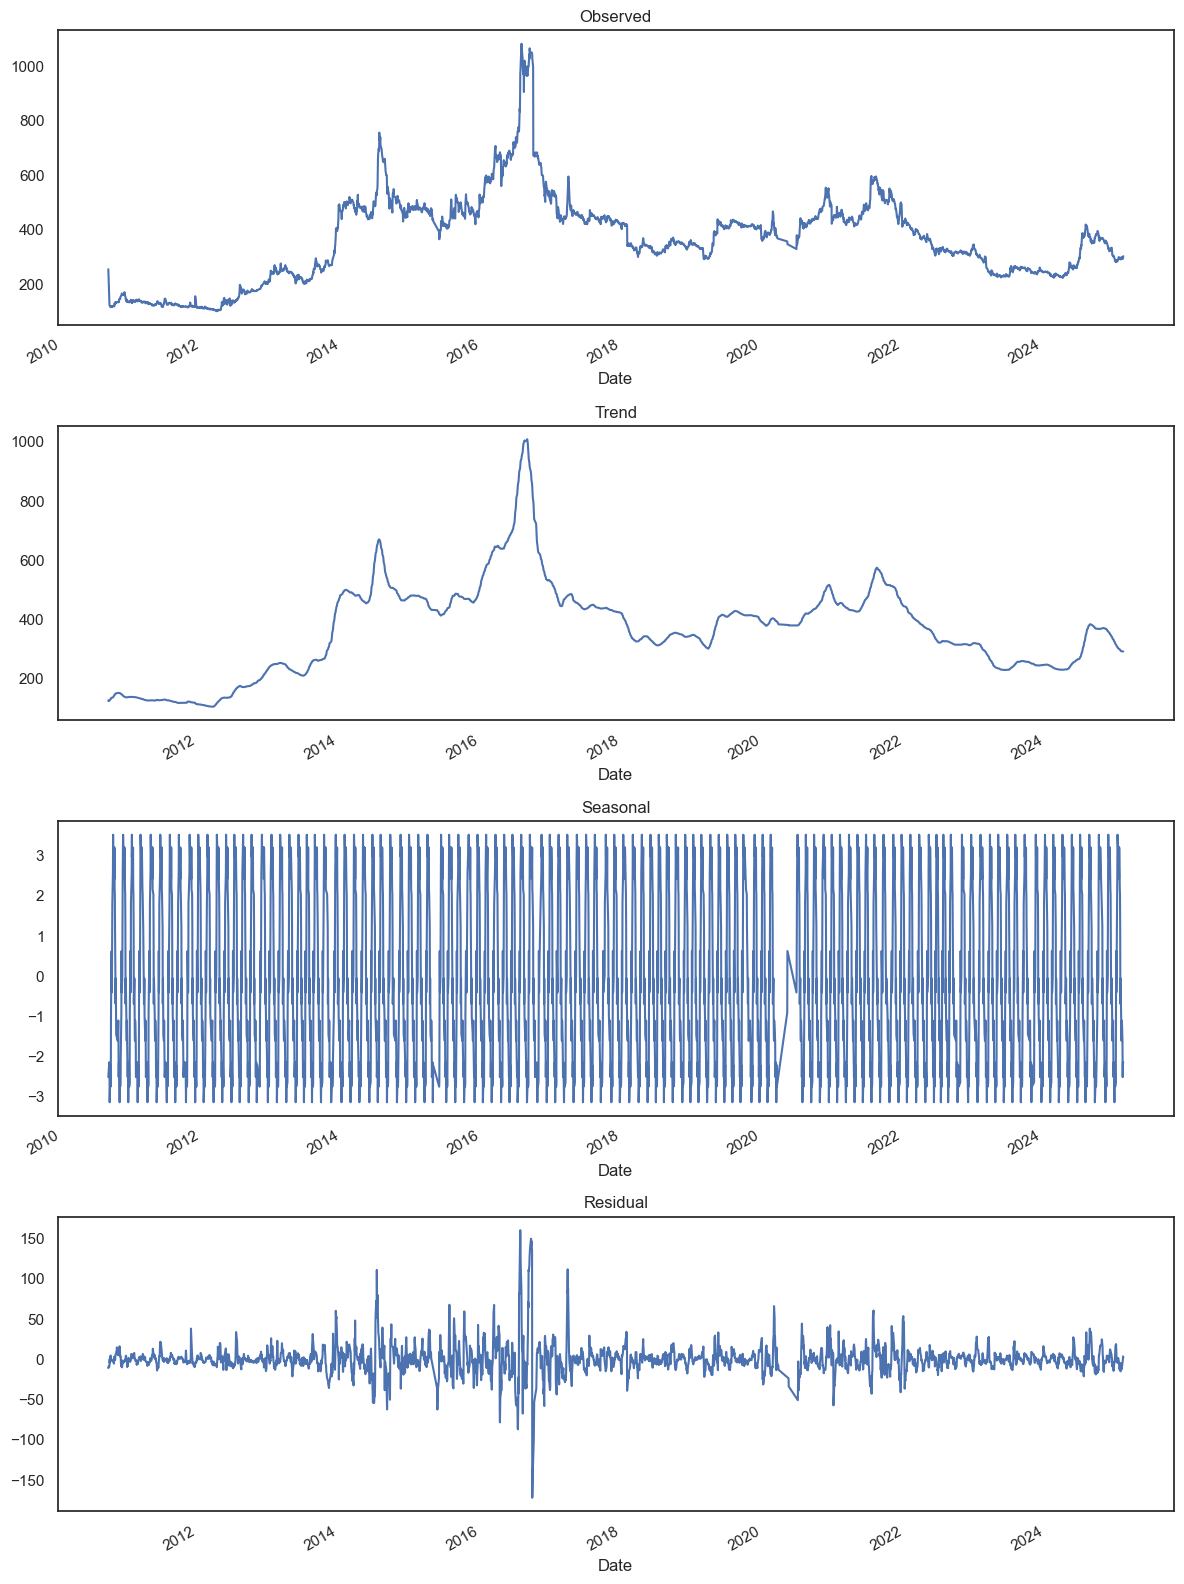

In [22]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16))
result.observed.plot(ax=ax1)
ax1.set_title('Observed')
result.trend.plot(ax=ax2)
ax2.set_title('Trend')
result.seasonal.plot(ax=ax3)
ax3.set_title('Seasonal')
result.resid.plot(ax=ax4)
ax4.set_title('Residual')
plt.tight_layout()
plt.show()

*  Interpretation of Each Component
* 1) Observed Plot (Top Graph)
*  Represents the raw time series data.

* We see an overall trend + seasonal variations (ups and downs).
* There are fluctuations indicating price movements over time.
* 2) Trend Component (Second Graph)
*  Shows the long-term movement in the data (upward/downward trends).

* There was an uptrend from 2020 to 2022, followed by a downtrend.
* This is useful for detecting if the data follows a structural pattern over time.
* * A strong trend component suggests ARIMA or LSTM might be useful.
* 3) Seasonal Component (Third Graph)
*  Captures repeating patterns at regular intervals.

* The data exhibits strong seasonality, with repeating cycles.
* There’s a disruption around 2021, possibly due to external events (e.g., market crashes, missing data).
* If seasonality is present, SARIMA (Seasonal ARIMA) or LSTMs with periodic inputs could be useful.
* 4) Residual Component (Fourth Graph)
* Represents random noise (unpredictable movements).

* Large residual spikes indicate periods of high volatility.
* If residuals are randomly distributed, the model successfully captures trend & seasonality.
* If residuals show patterns, the model might need improvement.

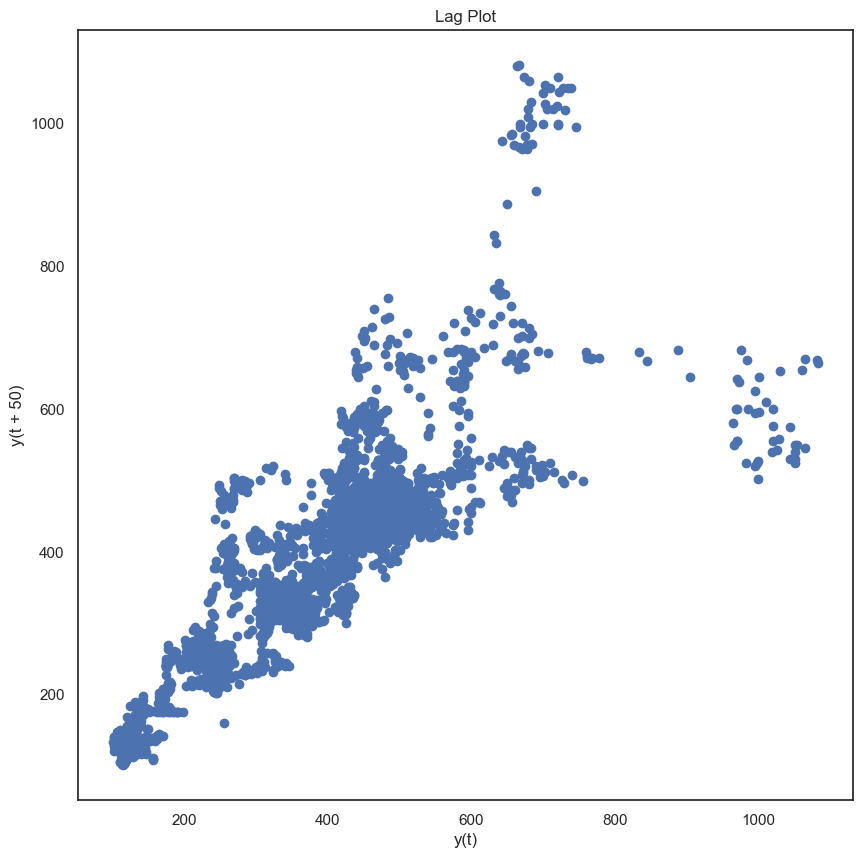

In [23]:
#lag plot
plt.figure(figsize=(10, 10))
lag_plot(close,lag=50) #check lag values at different steps to decide time-steps ie taking prev days values
plt.title('Lag Plot')
plt.show()

In [24]:
# We have not introduced ACF and PACF plots .
#plot of Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
# plot_acf(close, ax=ax1, lags=100)
# plot_pacf(close, ax=ax2, lags=100)
# plt.tight_layout()
# plt.show()

* Since ACF shows long-term dependence, use at least 60+ timesteps.
* Scaling is required to improve convergence.
### Observation:
* The ACF plot shows strong autocorrelation across all lags (gradual decline).
* This suggests a non-stationary time series (likely a trend or seasonality).
* To make the series stationary, differencing may be needed.


* ACF Analysis (Top Graph)
* Strong autocorrelation at all lags (slow decay) → Suggests a trend (non-stationary).
* Solution: Apply differencing (d=1) and recheck ACF.
* PACF Analysis (Bottom Graph)
* Strong spike at lag 1, then quick drop → Suggests an AR(1) process.
* Solution: Try ARIMA(1,1,0) after differencing.

In [25]:
#breaking into year monnth day and dayofweek
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['dayofweek'] = df.index.dayofweek

<Axes: xlabel='year'>

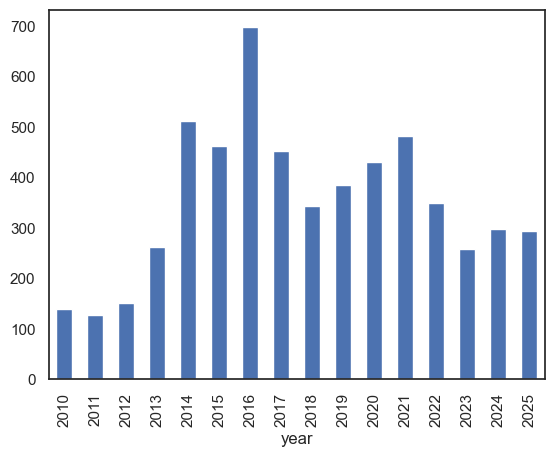

In [26]:
###################
# Yearly Close of nic

df.groupby('year')['Close'].mean().plot.bar()

<Axes: xlabel='month'>

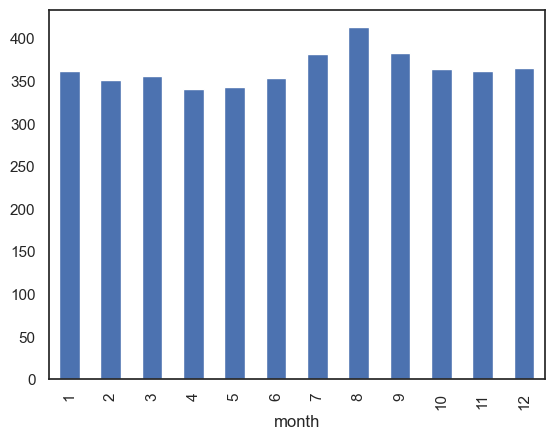

In [27]:
df.groupby('month')['Close'].mean().plot.bar()

<Axes: xlabel='day'>

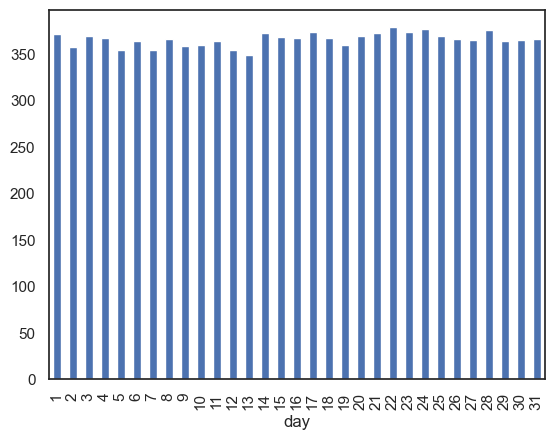

In [28]:
df.groupby('day')['Close'].mean().plot.bar()

<Axes: xlabel='dayofweek'>

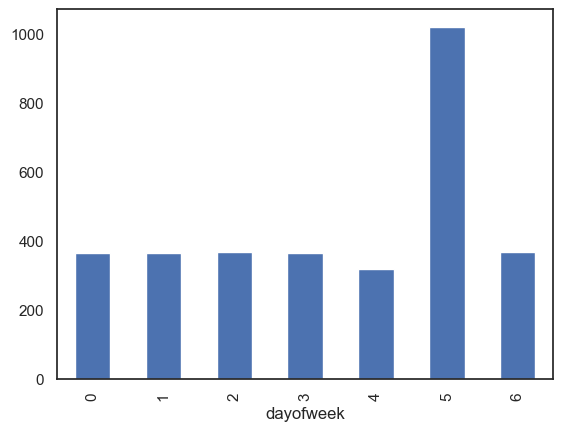

In [29]:
df.groupby('dayofweek')['Close'].mean().plot.bar()

In [30]:
df.head(1)

,Open,High,Low,Close,Qty,pchange,year,month,day,dayofweek
Date,,,,,,,,,,
2010-09-02,153.0,193.0,178.0,255.0,60.0,-45.882353,2010,9,2,3


In [31]:
df.drop(['year', 'month', 'day', 'dayofweek'], axis=1, inplace=True)

In [32]:
#data split

In [33]:
# Ensure all  columns are present (adjust if needed)
feature_columns = df.columns # Your 8 features
data = df[feature_columns].values
feature_columns,len(feature_columns)

(Index(['Open', 'High', 'Low', 'Close', 'Qty', 'pchange'], dtype='object'), 6)

### yaha samn same............................................................................

In [34]:
# Set random seed
random_seed = 42
np.random.seed(random_seed)
train_size = int(len(df) * 0.9)  # 9_0% train

test_size = len(df) - train_size # 10% test




X_train, X_test = (
    data[:train_size], 
    data[train_size:train_size + test_size]
    # X[train_size + val_size:]
)
y_train, y_test = (
   data[:train_size], 
   data[train_size:train_size + test_size]
    # y[train_size + val_size:]
)


In [35]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2972, 6), (331, 6), (2972, 6), (331, 6))

In [36]:
# Normalize Featuree
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))


X_train_scaled = scaler.fit_transform(X_train) 
# X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test )

y_train_scaled = scaler.transform(y_train)
# y_val_scaled = scaler.transform(y_val)
y_test_scaled = scaler.transform(y_test)

In [37]:
def create_sequences(x, y, n_steps):
    X_seq, y_seq = [], []
    for i in range(n_steps, len(y)):  # Ensure `y[i]` exists
        X_seq.append(x[i-n_steps:i])  # Take `n_steps` past values
        y_seq.append(y[i])  # Target at `i`
    return np.array(X_seq), np.array(y_seq)


n_steps =60 # Use past 100 days to predict next day's Close price

# Prepare sequences for Train, Validation, and Test sets
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, n_steps)
# X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, time_step)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, n_steps)

# Print final dataset shapes
print(f"Train sequences: {X_train_seq.shape}, {y_train_seq.shape}")
# print(f"Validation sequences: {X_val_seq.shape}, {y_val_seq.shape}")
print(f"Test sequences: {X_test.shape}, {y_test.shape}")


Train sequences: (2912, 60, 6), (2912, 6)
Test sequences: (331, 6), (331, 6)


In [38]:
X_train_seq.shape, X_test.shape

((2912, 60, 6), (331, 6))

In [39]:
X_train.shape

(2972, 6)

#### Building LSTM Modlel

In [40]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, kernel_regularizer=l2(0.001),input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(128, activation='tanh', return_sequences=True,kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    LSTM(64, activation='tanh', return_sequences=True,kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    LSTM(64, activation='tanh', return_sequences=True,kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    LSTM(32, activation='tanh', return_sequences=False,kernel_regularizer=l2(0.001)),
    # Dropout(0.2),
    Dense(X_train_seq.shape[2])
    
])
model.compile(optimizer='adam', loss='mse')

d:\ml\mlproject\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5)
]



In [42]:
# Train the model
lstm_Model = model.fit(X_train_seq, y_train_seq,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    callbacks=callbacks)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - loss: 0.3867 - val_loss: 0.1216 - learning_rate: 0.0010
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0921 - val_loss: 0.0387 - learning_rate: 0.0010
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0324 - val_loss: 0.0182 - learning_rate: 0.0010
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - loss: 0.0170 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0105 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0076 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - loss: 0.0058 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0051 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.0043 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 10/50


In [43]:
from datetime import datetime

# Get current date and time
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
model.save(f'DATE{current_time}Technicalindicatorsfinal_model_60.keras')

In [44]:
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
# model = load_model(f'indicatorsfinal_model_60.keras')

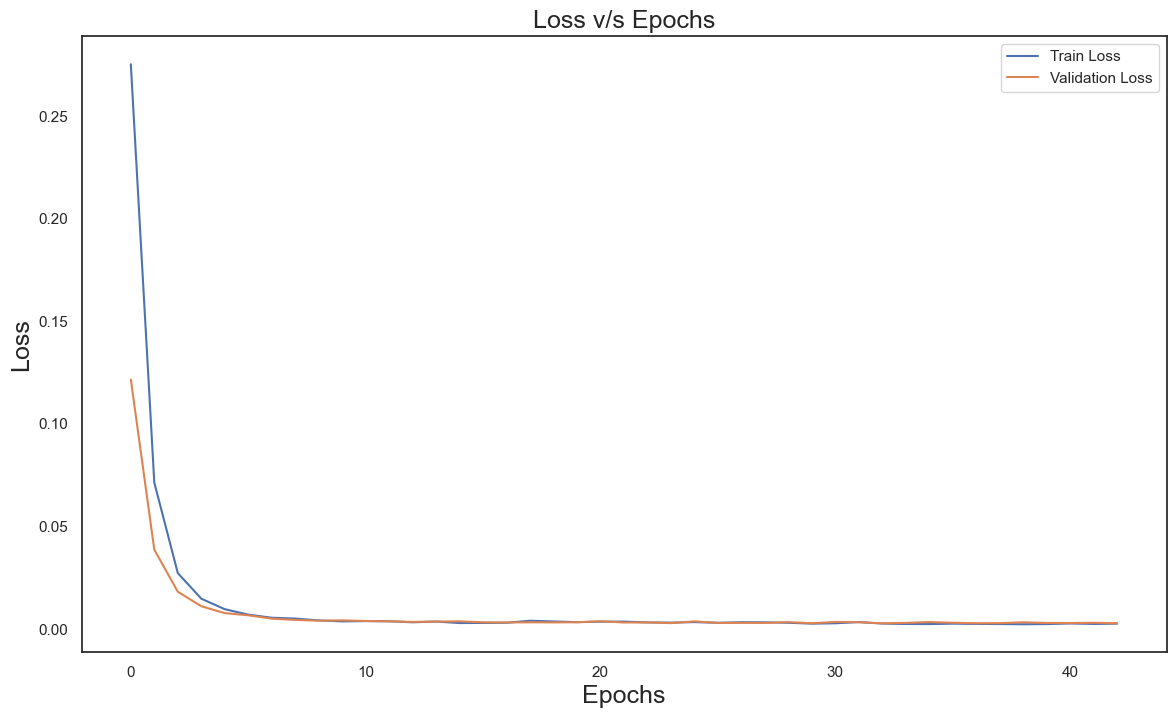

In [45]:
# Plot training & validation loss

plt.figure(figsize=(14, 8))
plt.plot(lstm_Model.history['loss'], label='Train Loss')
plt.plot(lstm_Model.history['val_loss'], label='Validation Loss')
plt.title('Loss v/s Epochs', fontsize=18)
plt.ylabel('Loss',fontsize=18)
plt.xlabel('Epochs',fontsize=18)
plt.legend()
plt.show()

In [46]:
## for the X_train
train_result=model.predict(X_train_seq)
train_result_inverse=scaler.inverse_transform(train_result)
train_result_close=train_result_inverse[:, 3]

91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step


In [47]:
## for the X_test
test_result=model.predict(X_test_seq)
test_result_inverse=scaler.inverse_transform(test_result)
test_result_close=test_result_inverse[:, 3]


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step


In [48]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
#for close price
print("MAE of close:", mean_absolute_error(y_test_seq[:,3], test_result[:,3]))
print("R² Score of close:", r2_score(y_test_seq[:,3], test_result[:,3]))
print("MSE of close:", mean_squared_error(y_test_seq[:,3], test_result[:,3]))
print("MAPE of close:", mean_absolute_percentage_error(y_test_seq[:,3], test_result[:,3]))

print("RMSE of close price:", np.sqrt(mean_squared_error(y_test_seq[:,3], test_result[:,3])))


MAE of close: 0.02360522478182044
R² Score of close: 0.6231055010998585
MSE of close: 0.0012666412834159832
MAPE of close: 0.1074869434990773
RMSE of close price: 0.03558990423443119


In [49]:
#for all price
print("MAE of close:", mean_absolute_error(y_test_seq, test_result))
print("R² Score of close:", r2_score(y_test_seq, test_result))
print("MSE of close:", mean_squared_error(y_test_seq, test_result))
print("MAPE of close:", mean_absolute_percentage_error(y_test_seq, test_result))

print("RMSE of close price:", np.sqrt(mean_squared_error(y_test_seq, test_result)))


MAE of close: 0.030162844951458146
R² Score of close: 0.34377517101996774
MSE of close: 0.003997212640878437
MAPE of close: 0.18676524827009022
RMSE of close price: 0.06322351335443513


In [50]:
#for training dataset

print("MAE of Test:", mean_absolute_error(y_test_seq, test_result))
print("R² Score TESt:", r2_score(y_test_seq, test_result))
print("MSE TESt:", mean_squared_error(y_test_seq, test_result))
print("MAPE of Test:", mean_absolute_percentage_error(y_test_seq, test_result))
print("MSE Train:", np.sqrt(mean_squared_error(y_train_seq, train_result)))



MAE of Test: 0.030162844951458146
R² Score TESt: 0.34377517101996774
MSE TESt: 0.003997212640878437
MAPE of Test: 0.18676524827009022
MSE Train: 0.0433848397845752


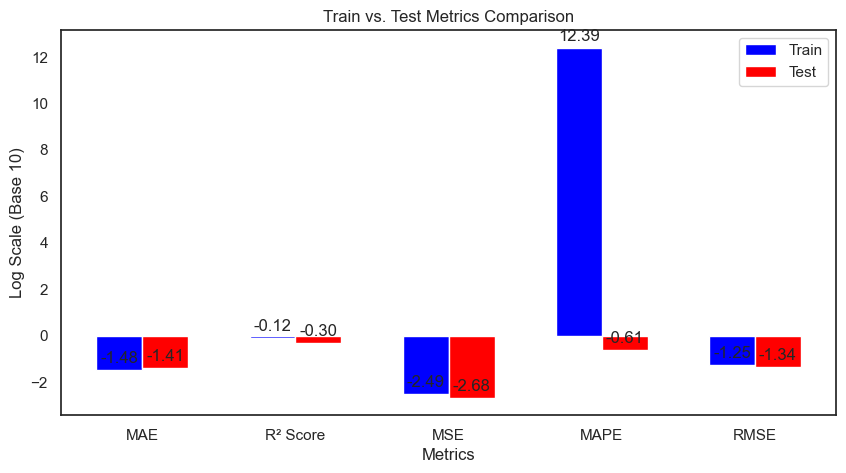

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics values
metrics = ['MAE', 'R² Score', 'MSE', 'MAPE', 'RMSE']
train_values = [0.03285, 0.7509, 0.00320, 2471872178591.562, 0.05663]
test_values = [0.03900, 0.4985, 0.00211, 0.2478, 0.04595]

# Fix scale issue (log scale for MAPE due to huge difference)
log_train_values = np.log10(train_values)
log_test_values = np.log10(test_values)

# Bar plot
x = np.arange(len(metrics))
width = 0.3  # Bar width

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, log_train_values, width, label='Train', color='blue')
bars2 = ax.bar(x + width/2, log_test_values, width, label='Test', color='red')

# Labels
ax.set_xlabel('Metrics')
ax.set_ylabel('Log Scale (Base 10)')
ax.set_title('Train vs. Test Metrics Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Show values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', 
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


In [52]:
X_test_seq.shape, X_train_seq.shape, y_test_seq.shape, y_train_seq.shape

((271, 60, 6), (2912, 60, 6), (271, 6), (2912, 6))

In [53]:
X_all = np.concatenate((X_train_scaled, X_test_scaled), axis=0)

X_all.shape

(3303, 6)

In [54]:
# Function to predict future days recursively (all 8 features)
def predict_future_multivariate(model, data, scaler, n_steps, future_days):
    predicted = []
    current_sequence = data[-n_steps:]  # Last window of data

    for _ in range(future_days):
        prediction = model.predict(current_sequence.reshape(1, n_steps, X_all.shape[1]), verbose=0)
        predicted.append(prediction[0])

        # Append predicted row to current sequence for next prediction
        current_sequence = np.vstack([current_sequence[1:], prediction])

    # Inverse transform all predicted data (8 features)
    predicted_array = np.array(predicted)
    predicted_prices = scaler.inverse_transform(predicted_array)
    return predicted_prices

In [55]:
# Predict next 30 days
n_steps = 60
future_days = 150
future_prices = predict_future_multivariate(model, X_all, scaler, n_steps, future_days)

In [56]:
n_steps

60

In [57]:
# Plot actual vs future Close prices
actual_close_prices = df['Close'].values

In [58]:
test_result.shape, train_result.shape, future_prices.shape,test_result_close.shape, train_result_close.shape

((271, 6), (2912, 6), (150, 6), (271,), (2912,))

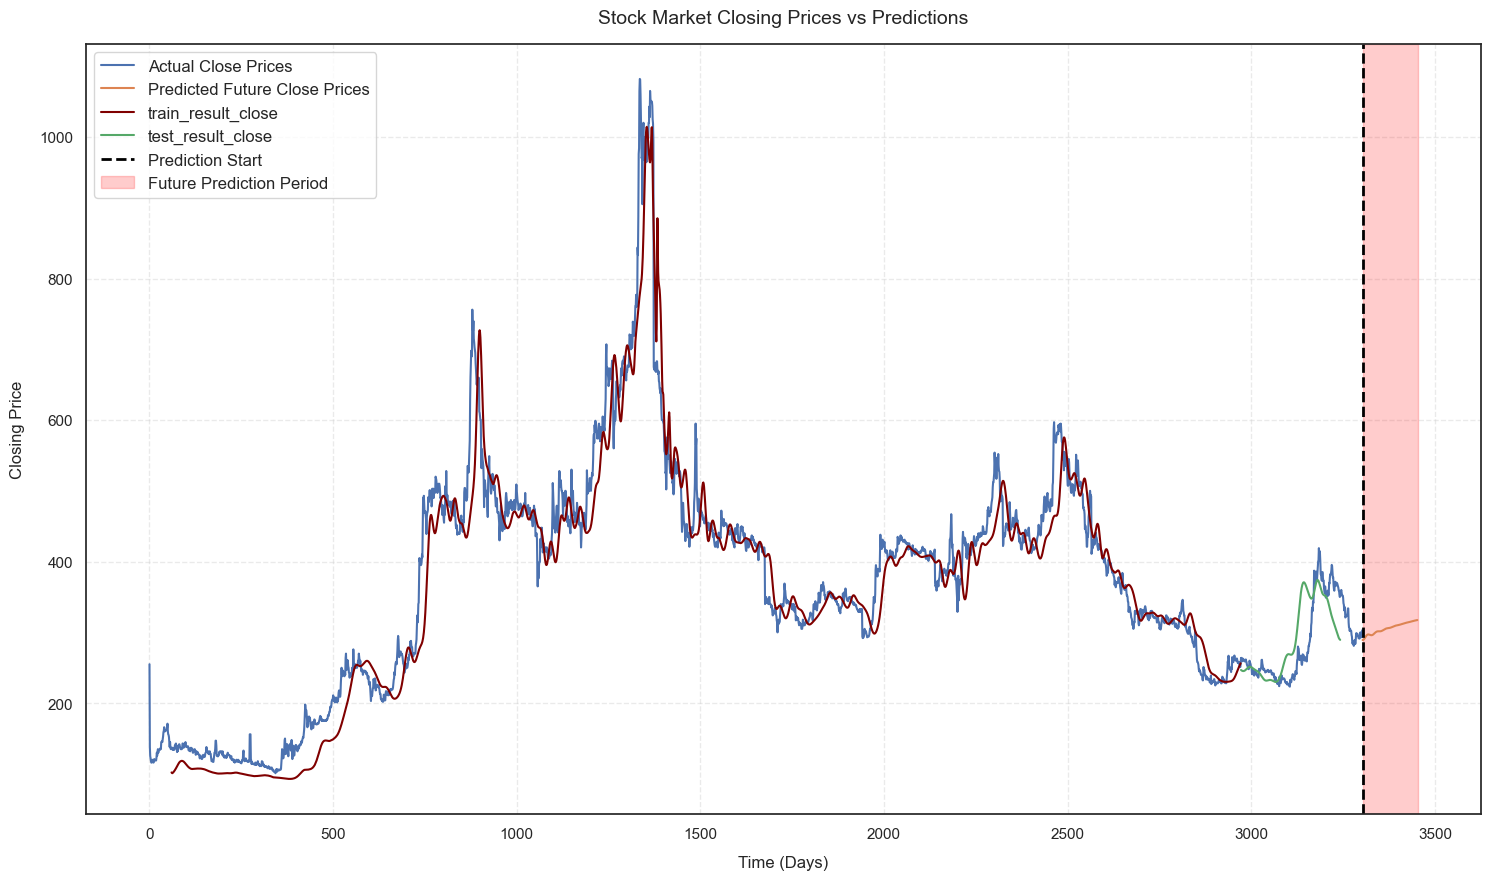

In [59]:
# Plot actual vs future Close prices

actual_close_prices = df['Close'].values
plt.figure(figsize=(18, 10))
plt.plot(actual_close_prices, label='Actual Close Prices')
plt.plot(range(len(actual_close_prices), len(actual_close_prices) + future_days), future_prices[:, 3], label='Predicted Future Close Prices')
plt.plot(range(n_steps, len(train_result_close)+n_steps),train_result_close,label="train_result_close", color="maroon" )
plt.plot(range(len(train_result_close)+n_steps, len(train_result_close)+len(test_result_close)+n_steps),test_result_close,label="test_result_close" )

plt.axvline(x=len(df), color='black', linestyle='--', linewidth=2, label="Prediction Start")

plt.axvspan(len(df), len(df)+future_days, color='red', alpha=0.2, label="Future Prediction Period")
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlabel("Time (Days)", fontsize=12, labelpad=10)
plt.ylabel("Closing Price", fontsize=12, labelpad=10)
plt.title("Stock Market Closing Prices vs Predictions", fontsize=14, pad=15)
plt.legend(fontsize=12, loc="upper left")

In [60]:
# Print predicted future prices (all features for each day)
future_df = pd.DataFrame(future_prices, columns=feature_columns)
future_df

,Open,High,Low,Close,Qty,pchange
0,292.670380,295.204956,289.080017,289.238495,15966.876953,-0.546681
1,292.640839,295.140839,289.084229,289.255188,16070.374023,-0.542520
2,292.812469,295.284851,289.287262,289.481537,16185.218750,-0.537233
3,293.167358,295.620728,289.670197,289.898346,16306.288086,-0.531001
4,293.677521,296.120789,290.204926,290.476105,16429.582031,-0.524085
...,...,...,...,...,...,...
145,319.690857,322.751770,316.028168,316.971893,17610.128906,-0.424157
146,319.797913,322.860107,316.133972,317.078979,17614.701172,-0.423822
147,319.906281,322.969543,316.241119,317.187500,17619.765625,-0.423459
148,320.016724,323.080994,316.350464,317.298340,17625.353516,-0.423078


In [61]:
# Save to CSV if needed
# future_df.to_csv(f'{current_time}predicted_future_prices.csv', index=False)

In [62]:
df['Close'].tail(),future_df['Close'].head()

(Date
 2025-02-20    296.0
 2025-02-23    294.0
 2025-02-24    293.9
 2025-02-25    293.1
 2025-02-27    303.0
 Name: Close, dtype: float64,
 0    289.238495
 1    289.255188
 2    289.481537
 3    289.898346
 4    290.476105
 Name: Close, dtype: float32)

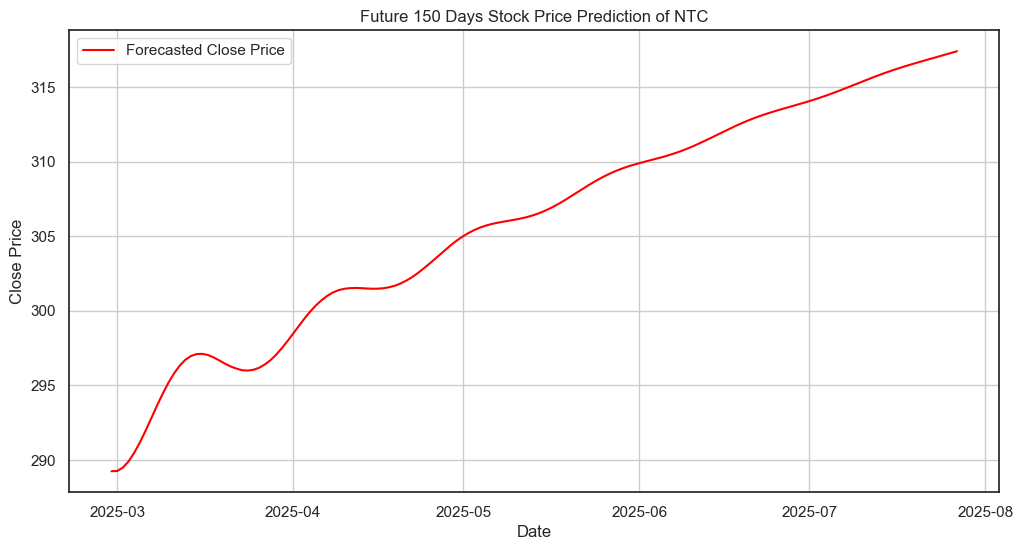

In [ ]:
# Plot forecasted values
# Convert to NumPy
future_predictions_close = np.array(future_prices[:, 3])

# Generate future dates correctly
last_date = pd.to_datetime(df.index[-1])  # Get last date from DataFrame index
future_dates = [last_date + pd.Timedelta(days=i) for i in range(1, future_days + 1)]


# Plot forecasted values
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_predictions_close, label="Forecasted Close Price", color="red")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title(f"Future {future_days} Days Stock Price Prediction ")
plt.legend()
plt.grid()
plt.show()

# # # Print predicted prices
# for date, price in zip(future_dates, future_predictions_close):
#     print(f"Date: {date.date()}, Predicted_Close_Price: {price:.2f}")

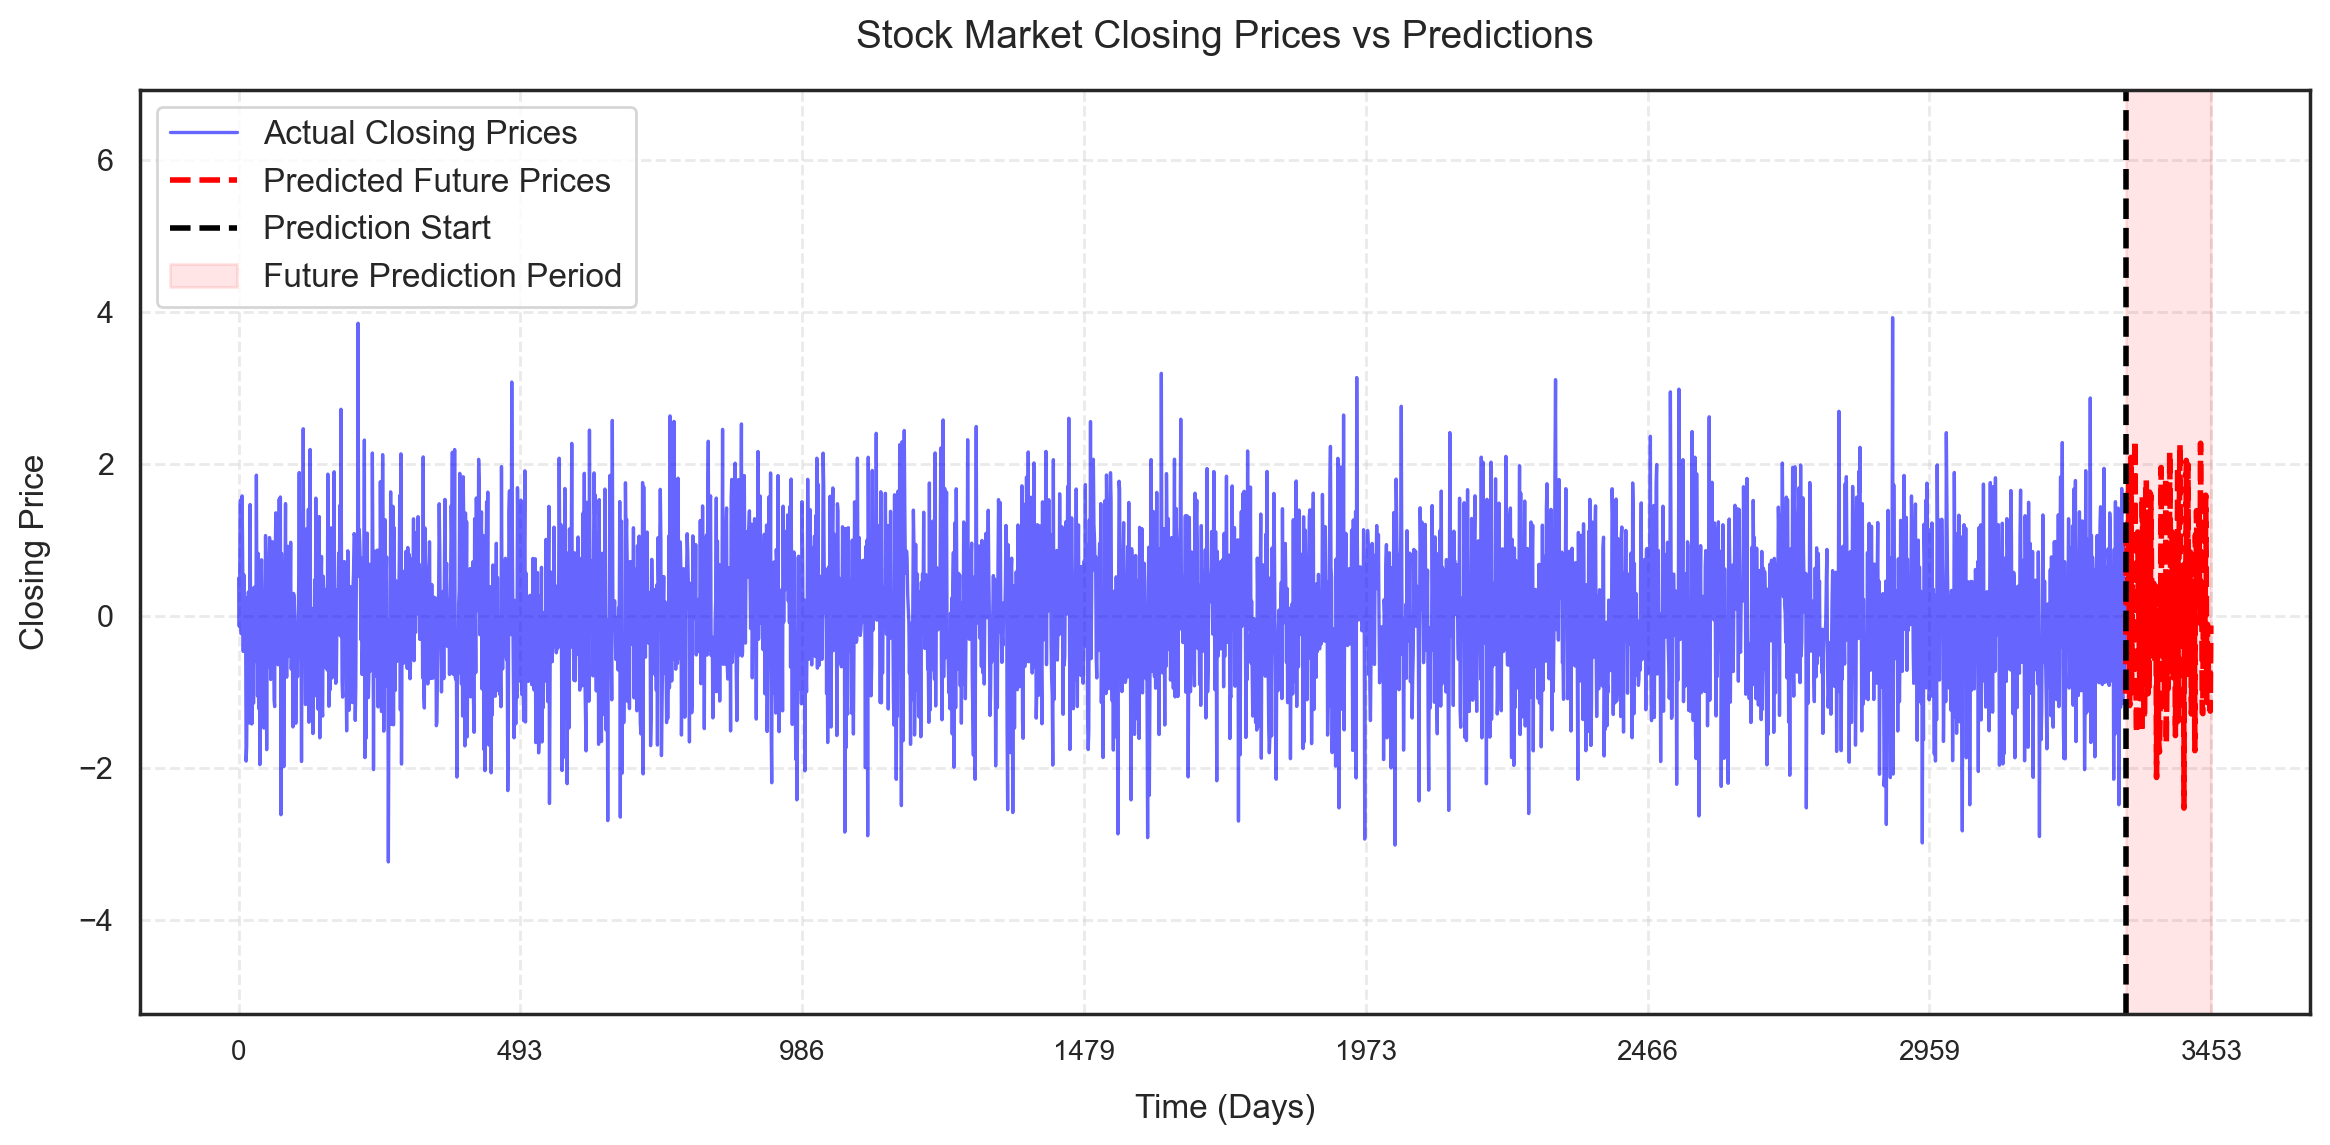

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated Data (Replace with your real data)
dates = np.arange(len(df)+future_days)  # Dates as index
actual_closing_prices = np.random.randn(len(df))  # Less noise in actual prices
predicted_prices = np.random.randn(future_days)  # Smoother predictions

# Create figure with better aspect ratio and higher DPI for clarity
plt.figure(figsize=(14, 6), dpi=200)
# Plot actual closing prices with reduced noise and opacity
plt.plot(dates[:len(df)], actual_closing_prices, label="Actual Closing Prices", 
         color='blue', linewidth=1.2, alpha=0.6)

# Plot predicted prices with a bolder dashed line
plt.plot(dates[len(df):], predicted_prices, label="Predicted Future Prices", 
         color='red', linestyle='dashed', linewidth=2)

# Vertical line to indicate forecast start
plt.axvline(x=len(df), color='black', linestyle='--', linewidth=2, label="Prediction Start")

# Shade the future prediction region
plt.axvspan(len(df), len(df)+future_days, color='red', alpha=0.1, label="Future Prediction Period")

# Adjust Y-axis limits for more price space
plt.ylim(min(actual_closing_prices) - 2, max(actual_closing_prices) + 3)

# Improve X-axis readability
plt.xticks(np.linspace(0, len(df)+future_days, num=8, dtype=int), fontsize=10)

# Labels, Title, and Legend with more spacing
plt.xlabel("Time (Days)", fontsize=12, labelpad=10)
plt.ylabel("Closing Price", fontsize=12, labelpad=10)
plt.title("Stock Market Closing Prices vs Predictions", fontsize=14, pad=15)
plt.legend(fontsize=12, loc="upper left")

# Grid adjustments for better clarity
plt.grid(True, linestyle='--', alpha=0.4)

# Show the improved plot
plt.show()

# for error calculation:

In [65]:
y_predicted=test_result_close[-20:]
print(y_predicted)

[316.0968  314.5282  312.945   311.32523 309.6779  308.01364 306.35913
 304.71088 303.04126 301.36032 299.6972  298.06992 296.51093 295.03897
 293.6787  292.45895 291.40128 290.54297 289.88474 289.44846]


In [66]:
dferror=pd.DataFrame(df["Close"].tail(20))
# dferror.reset_index(inplace=True)
dferror.head()

,Close
Date,
2025-01-27,283.5
2025-01-28,286.0
2025-02-02,294.9
2025-02-03,299.0
2025-02-04,297.0


In [67]:
dferror["Predicted"]=y_predicted
dferror["Error"]=abs((dferror["Close"]-dferror["Predicted"])/dferror["Close"]*100)
dferror.tail(20)

,Close,Predicted,Error
Date,,,
2025-01-27,283.5,316.096802,11.497990
2025-01-28,286.0,314.528198,9.974894
2025-02-02,294.9,312.945007,6.119026
2025-02-03,299.0,311.325226,4.122149
2025-02-04,297.0,309.677887,4.268649
2025-02-05,297.2,308.013641,3.638507
2025-02-06,298.0,306.359131,2.805077
2025-02-09,295.0,304.710876,3.291823
2025-02-10,295.0,303.041260,2.725851


In [68]:
import numpy as np
AvgError=np.mean(dferror["Error"])
AvgError

np.float64(3.4447066386004423)

In [69]:
dferror.to_csv("NoPEEPSsnsfuture_df.csv", index=False)